## Three Link with Twist

<img src="https://faculty.gvsu.edu/kraussry/445_images/jacobian_robots/Jacobian_robot_third_link_twist2026_07_05_19_37_36_excalidraw.png" width=400px>

## Problem Statement

- find the singularity conditions for the three-link robot show above
- this is essentially a third link attached to the two link example
- $\hat{Z}_1$ and $\hat{Z}_2$ are parallel
- $\hat{Z}_3$ is perpendicular to $\hat{Z}_2$

## Steps:

- Find a symbolic expression for the velocity of the tip of the robot using `sympy`.
- Take partial derivatives of $\bar{v}_{tip}$ to find the Jacobian of the robot.
- Take the determinant of your Jacobian to find the singularity conditions

In [40]:
import sympy
from sympy.interactive import printing
printing.init_printing(use_latex=True)
import robotics_sympy
p90 = sympy.pi/2
n90 = -p90

## Properly defining nice looking symbols

In [3]:
th1, th1dot, th2, th2dot, L1, L2 = sympy.symbols(['\\theta_1','\\dot{\\theta}_1','\\theta_2','\\dot{\\theta}_2','L_1','L_2'])

In [23]:
th3, th3dot, L3 = sympy.symbols(['\\theta_3','\\dot{\\theta}_3','L_3'])

In [24]:
th1

In [25]:
th1dot

 From eqn. 5.46:
 
 $$^iv_{i+1} = \; ^iv_i + ^i\omega_i \times ^iP_{i+1}$$

**Note:** you will need to use eqn. 5.45 to find the rotational velocity of the final link because $\hat{Z}_3$ is not parallel to $\hat{Z}_2$: 

$$^{i+1}\omega_{i+1} = \; ^{i+1}_i \mathbf{R} \cdot ^i\omega_i + \dot{\theta}_{i+1} \, ^{i+1} \hat{Z}_{i+1}$$

## Copying Code from Two-Link Example to get out to link 3:

In [26]:
v1f1 = sympy.Matrix([[0],[0],[0]])
v1f1

$^1\omega_1$:

- the rotational velocity of link 1 in frame 1:

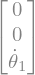

In [27]:
w1f1 = sympy.Matrix([[0],[0],[th1dot]])
w1f1

$^1P_2$:

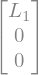

In [28]:
P2f1 = sympy.Matrix([[L1],[0],[0]])
P2f1

$^1v_2$:

$$^1v_{2} = \; ^1v_1 + ^1\omega_{1} \times  ^1P_{2}$$

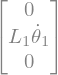

In [29]:
v2f1 = v1f1 + w1f1.cross(P2f1)
v2f1

$^2v_2$:

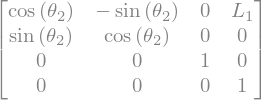

In [30]:
T12 = robotics_sympy.DH(0,L1,th2,0)
T12

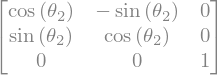

In [31]:
R12 = T12[0:3,0:3]
R12

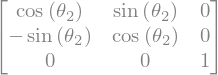

In [32]:
R21 = R12.T
R21

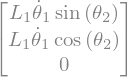

In [33]:
v2f2 = R21@v2f1
v2f2

$^2v_{tip} = \; ^2v_3$:

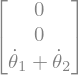

In [34]:
w2f2 = R21@w1f1 + sympy.Matrix([[0],[0],[th2dot]])
w2f2

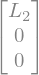

In [35]:
P3f2 = sympy.Matrix([[L2],[0],[0]])
P3f2

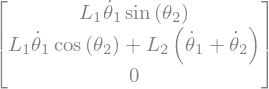

In [36]:
v3f2 = v2f2 + w2f2.cross(P3f2)
v3f2

## End of Two Link Code

- we have the velocity of $O_3$ in frame 2
- the tip is at $O_4$, so we need $^3\bar{v}_{tip} = ^3\bar{v}_4$:

 From eqn. 5.46:
 
 $$^iv_{i+1} = \; ^iv_i + ^i\omega_i \times ^iP_{i+1}$$

for the last link, $i = 3$ and $i+1 = 4$.

$$^3\bar{v}_3 = ^3_2\mathbf{R} \cdot ^2\bar{v}_3$$

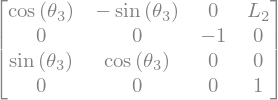

In [41]:
T23 = robotics_sympy.DH(p90,L2,th3,0)
T23

In [43]:
R23 = T23[0:3,0:3]

In [44]:
R32 = R23.T

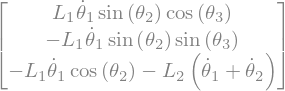

In [46]:
v3f3 = R32@v3f2
v3f3

$$^3\bar{\omega}_3 = \; ^3_2\mathbf{R} \cdot ^2\bar{\omega}_2 + \begin{bmatrix}0 \\ 0 \\ \dot{\theta}_3 \end{bmatrix}$$

## Key Takeaway for Three Link Example:

When our $\hat{Z}$ axes are not parallel, we must rotate $^i\bar{\omega}_i$ into frame $i+1$ before adding components together to find $^{i+1}\bar{\omega}_{i+1}$:

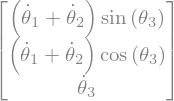

In [48]:
w3f3 = R32@w2f2 + sympy.Matrix([[0],[0],[th3dot]])
w3f3

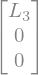

In [49]:
P4f3 = sympy.Matrix([[L3],[0],[0]])
P4f3

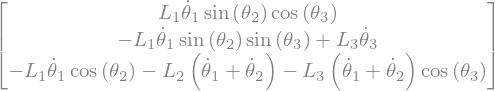

In [51]:
v4f3 = vtipf3 = v3f3 + w3f3.cross(P4f3)
v4f3

In [52]:
def J_row(v, theta_dots):
    row_list = []
    for theta_dot in theta_dots:
        #print("theta_dot = %s" % theta_dot)
        item = v.diff(theta_dot)
        row_list.append(item)
    return row_list

In [53]:
def find_J(vtip, theta_dots):
    J_list = []
    for v in vtip:
        cur_row = J_row(v,theta_dots)#<-- find the row of the Jacobian for vtip[0], vtip[1], ...
        J_list.append(cur_row)
    return sympy.Matrix(J_list)

In [54]:
J_row0 = J_row(v4f3[0],[th1dot, th2dot, th3dot])
J_row0

In [55]:
J_row1 = J_row(v4f3[1],[th1dot, th2dot, th3dot])
J_row1

In [56]:
J_row2 = J_row(v4f3[2],[th1dot, th2dot, th3dot])
J_row2

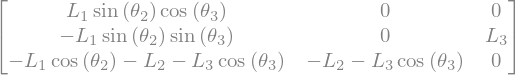

In [57]:
J = find_J(vtipf3, [th1dot, th2dot, th3dot])
J

In [59]:
det_J = J.det()
det_J

In [60]:
det_J.simplify()